In [226]:
import pandas as pd 
df = pd.read_csv("Animal_Dataset.csv") #loads in csv file into dataframe 

### Search func


In [227]:
def search_animal(animal):
    
    result = df[df["Animal"].str.lower() == animal.lower()]     #look for animal
    if result.empty:
        return "Search not found"
    
    return result.iloc[0].to_dict()     #return result as dictionary

search_animal("Saola")

{'Animal': 'Saola',
 'Height (cm)': 'Up to 90',
 'Weight (kg)': 'Up to 100',
 'Color': 'Brown, White',
 'Lifespan (years)': 'Up to 21',
 'Diet': 'Herbivore',
 'Habitat': 'Forests',
 'Predators': 'Tigers, Leopards',
 'Average Speed (km/h)': '26',
 'Countries Found': 'Vietnam, Laos',
 'Conservation Status': 'Critically Endangered',
 'Family': 'Bovidae',
 'Gestation Period (days)': '240',
 'Top Speed (km/h)': '26',
 'Social Structure': 'Solitary',
 'Offspring per Birth': '1'}

### Testing Wikipedia for images

Code below can find images of animals from wikipedia (returns no images found if no animal found)

In [228]:
import requests
import os
import shutil


HEADERS = {
    "User-Agent": "AnimalImageFetcher/1.0 (your_email@example.com)"
}

WIKI_API = "https://en.wikipedia.org/w/api.php"

LOCAL_IMAGE_MAP = {     #local manually added images
    "Blobfish": "static/images/Blobfish.jpeg",
    "Fossa": "static/images/Fossa.jpeg",
    "Kiwi": "static/images/kiwi.jpeg",
    "Red-Eyed Tree Frog": "static/images/red-eye tree frog.jpeg",
    "Amazon Rainforest Frog": "static/images/Amz rainforest frog.jpeg",
    "Titanaboa": "static/images/Titanoboa.jpeg",
    "Woolly Mammoth": "static/images/woolly mammoth.jpeg",
}

def resolve_title(animal_name):     #uses full search engine (searches multiple articles)
    params = {
        "action": "query",
        "list": "search",
        "srsearch": animal_name,
        "format": "json"
    }

    r = requests.get(WIKI_API, params=params, headers=HEADERS)
    r.raise_for_status()
    results = r.json().get("query", {}).get("search", [])

    #return top ranked page in wiki
    return results[0]["title"] if results else None


def get_animal_image(animal_name):
    
    #check if it's manually added
    if animal_name in LOCAL_IMAGE_MAP:
        path = LOCAL_IMAGE_MAP[animal_name]
        if os.path.exists(path):
            return path   # local file path
        else:
            print(f"Missing local image file: {path}")
    
    #look for image directly
    params = {
        "action": "query",
        "titles": animal_name,
        "prop": "pageimages",
        "format": "json",
        "pithumbsize": 1000,
        "redirects": 1      #allows page redirect
    }

    r = requests.get(WIKI_API, params=params, headers=HEADERS)
    r.raise_for_status()
    page = next(iter(r.json()["query"]["pages"].values()))

    if "thumbnail" in page:
        return page["thumbnail"]["source"]

    # Search fallback
    resolved = resolve_title(animal_name)       #try another page
    if not resolved:
        return None

    params["titles"] = resolved     #get image from other page
    r = requests.get(WIKI_API, params=params, headers=HEADERS)
    r.raise_for_status()
    page = next(iter(r.json()["query"]["pages"].values()))

    return page.get("thumbnail", {}).get("source")

def download_image(image_source, filename):
    if not image_source:
        return

    # Wikipedia / remote image
    if image_source.startswith("http"):
        response = requests.get(image_source, headers=HEADERS)
        if response.status_code == 200:
            with open(filename, "wb") as f:
                f.write(response.content)

    # Local image path
    else:
        if os.path.exists(image_source):
            shutil.copy(image_source, filename)
        else:
            print(f"Local image not found: {image_source}")

# ---- Test ----
animal = "African Lion"
image_url = get_animal_image(animal)

if image_url:
    print("Image found:", image_url)
    download_image(image_url, f"{animal}.jpg")
else:
    print("No image found")

Image found: https://upload.wikimedia.org/wikipedia/commons/thumb/a/a6/020_The_lion_king_Snyggve_in_the_Serengeti_National_Park_Photo_by_Giles_Laurent.jpg/1280px-020_The_lion_king_Snyggve_in_the_Serengeti_National_Park_Photo_by_Giles_Laurent.jpg


### See how many images cannot be found

# Load dataset
df = pd.read_csv("Animal_Dataset.csv")

animals_with_no_image = []
animals_with_image = []

for animal in df["Animal"]:
    image_url = get_animal_image(animal)
    
    if image_url is None:
        animals_with_no_image.append(animal)
    else:
        animals_with_image.append(animal)

print(animals_with_no_image)
print(len(animals_with_no_image))

print(animals_with_image) 
print(len(animals_with_image))

## Testing images for maps

In [229]:
set(df["Countries Found"])      #returns all unique value in "Countries Found" (len=102)


{'Africa',
 'Africa, Asia, Americas',
 'Africa, Asia, Australia, Oceania',
 'Africa, Iran, India',
 'Africa, Middle East',
 'All Oceans',
 'Amazon Rainforest',
 'Americas',
 'Antarctica',
 'Arctic',
 'Arctic, Atlantic Ocean',
 'Arctic, North America',
 'Argentina',
 'Argentina, Chile',
 'Asia',
 'Asia, Africa',
 'Asia, Australia',
 'Asia, Russia',
 'Atlantic Ocean, Arctic',
 'Atlantic Ocean, Gulf of Mexico',
 'Australia',
 'Australia, New Guinea',
 'Australia, New Zealand',
 'Australia, New Zealand, Tasmania',
 'Borneo',
 'Borneo, Malaysia',
 'Brazil',
 'Central Africa',
 'Central Asia',
 'Central Asia, South Asia, Middle East',
 'China',
 'China, Nepal, Bhutan, India',
 'Democratic Republic of the Congo',
 'Democratic Republic of the Congo, Uganda',
 'Eastern Africa',
 'Eastern Pacific Ocean',
 'Europe',
 'Europe, Asia',
 'Europe, Asia, Africa, Americas',
 'Europe, Asia, North America, Africa',
 'Galápagos Islands',
 'Gulf of California, Mexico',
 'India',
 'India, Bangladesh, Nepal',

In [233]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import re

WORLD_URL = ("https://naturalearth.s3.amazonaws.com/"
            "110m_cultural/ne_110m_admin_0_countries.zip")

OCEAN_URL = ("https://naturalearth.s3.amazonaws.com/"
            "50m_physical/ne_50m_geography_marine_polys.zip")

# --- Custom Region Groups ---
REGION_ALIASES = {
    "americas": ["North America", "South America"],
    "amazon rainforest": ["Brazil", "Peru", "Bolivia", "Ecuador", 
                        "Colombia", "Venezuela", "French Guiana", "Guyana", "Suriname"],
    "central america": ["Mexico", "Guatemala", "Belize", "Honduras",
                        "El Salvador", "Nicaragua", "Costa Rica", "Panama"],
    "middle east": ["Saudi Arabia", "Iran", "Iraq", "Israel", "Jordan",
                    "United Arab Emirates", "Qatar", "Kuwait",
                    "Oman", "Yemen", "Syria", "Lebanon"],
    "indian subcontinent": ["India", "Pakistan", "Bangladesh", "Nepal",
                            "Bhutan", "Sri Lanka"],
    "north africa": ["Africa"],
    "indonesia": ["Indonesia"],
    "borneo": ["Indonesia", "Malaysia", "Brunei"],
    "sumatra": ["Indonesia"],
    "southeast asia": ["Asia"],
    "south asia": ["Asia"],
    "tasmania": ["Australia"],
    "galápagos islands": ["Ecuador"],
    "new guinea": ["Papua New Guinea", "Indonesia"],
    "sub-saharan africa": ["Africa"],  # simplified
    "indo-pacific region": ["Indian Ocean", "Pacific Ocean"],
    "all oceans": ["Pacific Ocean", "Atlantic Ocean",
                "Indian Ocean", "Arctic Ocean", "Southern Ocean"],
    "oceans worldwide": ["Pacific Ocean", "Atlantic Ocean",
                        "Indian Ocean", "Arctic Ocean", "Southern Ocean"],
    "worldwide": ["Africa", "Asia", "Europe",
                "North America", "South America", "Oceania", "Antarctica"],
    "northern hemisphere": ["North America", "Europe", "Asia"],
}

# Words to remove (ignore cardinal directions)
REMOVE_WORDS = ["western", "eastern", "northern", "southern",
    "central", "tropical"]


def clean_region_name(name):
    name = name.lower()

    # remove direction words
    for word in REMOVE_WORDS:
        name = re.sub(rf"\b{word}\b", "", name)

    name = name.replace("(", "").replace(")", "")
    name = name.strip()

    return name


def highlight_region(input_string, show_map=True):

    world = gpd.read_file(WORLD_URL)
    world.columns = world.columns.str.lower()
    oceans = gpd.read_file(OCEAN_URL)
    oceans.columns = oceans.columns.str.lower()

    regions = [r.strip() for r in input_string.split(",")]

    matches = []

    for region_raw in regions:

        region = clean_region_name(region_raw)

        # --- Alias group ---
        if region in REGION_ALIASES:
            for subregion in REGION_ALIASES[region]:

                # Ocean inside alias
                ocean_match = oceans[oceans["name_en"].str.lower() == subregion.lower()]
                
                if not ocean_match.empty:
                    matches.append(ocean_match)
                    continue

                # Continent inside alias
                continent_match = world[world["continent"].str.lower() == subregion.lower()]
                
                if not continent_match.empty:
                    matches.append(continent_match)
                    continue

                # Country inside alias
                country_match = world[world["admin"].str.lower() == subregion.lower()]
                
                if not country_match.empty:
                    matches.append(country_match)
            continue

        # --- Continent ---
        continent_match = world[world["continent"].str.lower() == region]
        
        if not continent_match.empty:
            matches.append(continent_match)
            continue

        # --- Country ---
        country_match = world[world["admin"].str.lower() == region]
        
        if not country_match.empty:
            matches.append(country_match)
            continue

        # --- Ocean ---
        ocean_match = oceans[oceans["name_en"].str.lower() == region]
        
        if not ocean_match.empty:
            matches.append(ocean_match)
            continue

        # --- Arctic ---
        if region == "arctic":
            arctic_box = box(-180, 66.5, 180, 90)
            arctic_gdf = gpd.GeoDataFrame(geometry=[arctic_box], crs=world.crs)
            matches.append(arctic_gdf)
            continue

        if not matches:
            return -1

    if show_map:
        fig, ax = plt.subplots(figsize=(12, 6))

        world.plot(ax=ax, color="lightgray", edgecolor="white")
        oceans.plot(ax=ax, color="lightblue", edgecolor="lightblue")

        for match in matches:
            match.plot(ax=ax, color="green", edgecolor="black", alpha=0.7)

        ax.set_title(f"Highlighted: {input_string}")
        ax.axis("off")
        plt.show()



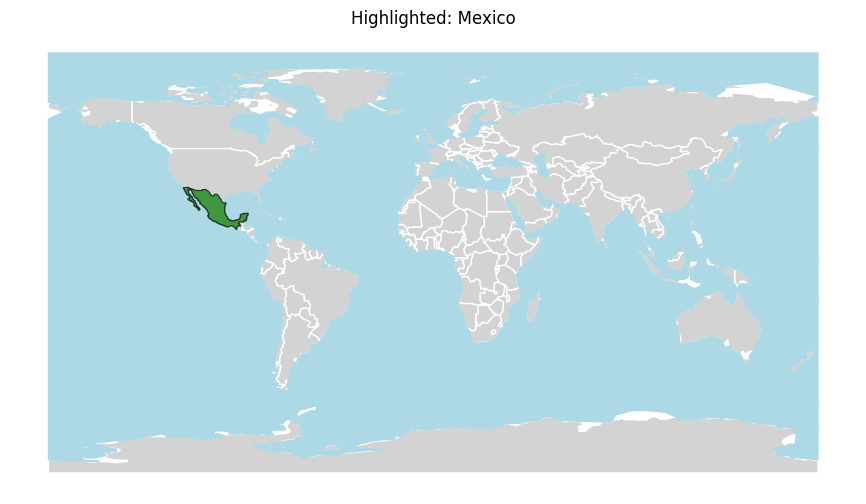

In [234]:
highlight_region('Mexico')


### Test all regions

In [232]:
failed_regions = []

unique_regions = set(df["Countries Found"])

for region in unique_regions:
    result = highlight_region(region, show_map=False)
    
    if result == -1:
        failed_regions.append(region)

print("Total regions tested:", len(unique_regions))
print("Total failures:", len(failed_regions))
print("\nRegions that failed:")
print(failed_regions)

Highlighted continent: Asia
Highlighted region group: Middle East
Highlighted continent: Africa
Highlighted region group: Sumatra
Highlighted country: Australia
Highlighted country: New Zealand
Highlighted region group: Tasmania
Highlighted region group: Southeast Asia
Highlighted region group: All Oceans
Highlighted country: Madagascar
Highlighted country: Mexico
Highlighted continent: South America
Highlighted continent: Asia
Highlighted country: Russia
Highlighted country: United States of America
Highlighted continent: Asia
Highlighted country: Australia
Highlighted region group: Worldwide
Highlighted continent: Africa
Highlighted region group: Middle East
Highlighted region group: Indian subcontinent
Highlighted continent: South America
Highlighted continent: Asia
Highlighted ocean: Western Indian Ocean
Highlighted continent: Eastern Africa
Highlighted region group: Borneo
Highlighted country: Malaysia
Highlighted continent: Europe
Highlighted country: Papua New Guinea
Highlighted